# 04_lstm_baseline

Goals:
- load sequence arrays for FD001
- build a baseline LSTM model in PyTorch
- train the model for RUL prediction
- evaluate the model on the test set
- visualize training behavior and predictions
- save the trained model and prediction results

In [54]:
import torch
import numpy as np
import random

seed = 9

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [55]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

In [56]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_NAME = "lstm_baseline_seq30_cap100"
print("Running experiment:", EXPERIMENT_NAME)

Running experiment: lstm_baseline_seq30_cap100


In [57]:
X_train = np.load(PROCESSED_DIR / "X_train.npy")
y_train = np.load(PROCESSED_DIR / "y_train.npy")
X_test = np.load(PROCESSED_DIR / "X_test.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")



print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17731, 30, 15)
y_train shape: (17731,)
X_test shape: (100, 30, 15)
y_test shape: (100,)


In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [59]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)

X_train tensor shape: torch.Size([17731, 30, 15])
y_train tensor shape: torch.Size([17731, 1])


In [60]:
dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(9)
)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 222
Validation batches: 56
Test batches: 2


In [61]:
class LSTMRULModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)

        last_hidden = hidden[-1]
        output = self.regressor(last_hidden)

        return output

In [62]:
input_size = X_train.shape[2]

model = LSTMRULModel(
    input_size=input_size,
    hidden_size=64,
    num_layers=1,
    dropout=0.0
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

LSTMRULModel(
  (lstm): LSTM(15, 64, batch_first=True)
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [63]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            all_preds.append(predictions.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    all_preds = np.vstack(all_preds).flatten()
    all_targets = np.vstack(all_targets).flatten()

    return epoch_loss, all_preds, all_targets

In [64]:
EPOCHS = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_path = MODELS_DIR / f"{EXPERIMENT_NAME}.pt"

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("Best validation loss:", best_val_loss)
print("Best model saved to:", best_model_path)

Epoch 01/30 | Train Loss: 3001.8827 | Val Loss: 1099.7239
Epoch 02/30 | Train Loss: 1097.3251 | Val Loss: 1099.3197
Epoch 03/30 | Train Loss: 1097.1402 | Val Loss: 1098.8627
Epoch 04/30 | Train Loss: 1090.4017 | Val Loss: 1056.2318
Epoch 05/30 | Train Loss: 572.5074 | Val Loss: 176.2929
Epoch 06/30 | Train Loss: 126.9300 | Val Loss: 166.5480
Epoch 07/30 | Train Loss: 101.2278 | Val Loss: 89.7410
Epoch 08/30 | Train Loss: 99.0288 | Val Loss: 93.1553
Epoch 09/30 | Train Loss: 92.3386 | Val Loss: 88.4003
Epoch 10/30 | Train Loss: 90.0569 | Val Loss: 82.2999
Epoch 11/30 | Train Loss: 85.8461 | Val Loss: 86.4674
Epoch 12/30 | Train Loss: 84.6804 | Val Loss: 79.0261
Epoch 13/30 | Train Loss: 82.4556 | Val Loss: 88.1178
Epoch 14/30 | Train Loss: 85.3452 | Val Loss: 80.7761
Epoch 15/30 | Train Loss: 81.4324 | Val Loss: 87.4103
Epoch 16/30 | Train Loss: 81.4489 | Val Loss: 74.5727
Epoch 17/30 | Train Loss: 79.8210 | Val Loss: 77.9741
Epoch 18/30 | Train Loss: 79.7829 | Val Loss: 83.7791
Epoch 1

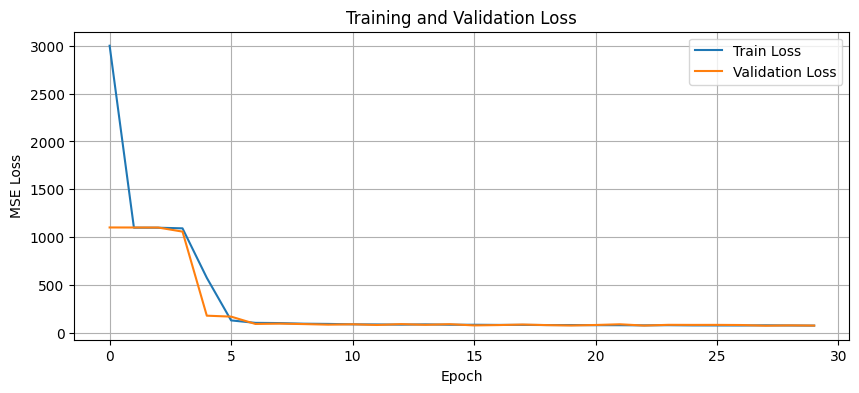

In [65]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, y_pred, y_true = evaluate(model, test_loader, criterion, device)
y_pred = np.clip(y_pred, 0, None)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Test Loss (MSE):", test_loss)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Test Loss (MSE): 301.1561962890625
Test RMSE: 17.353853159526903
Test MAE: 12.807908058166504
Test R2: 0.8256056904792786


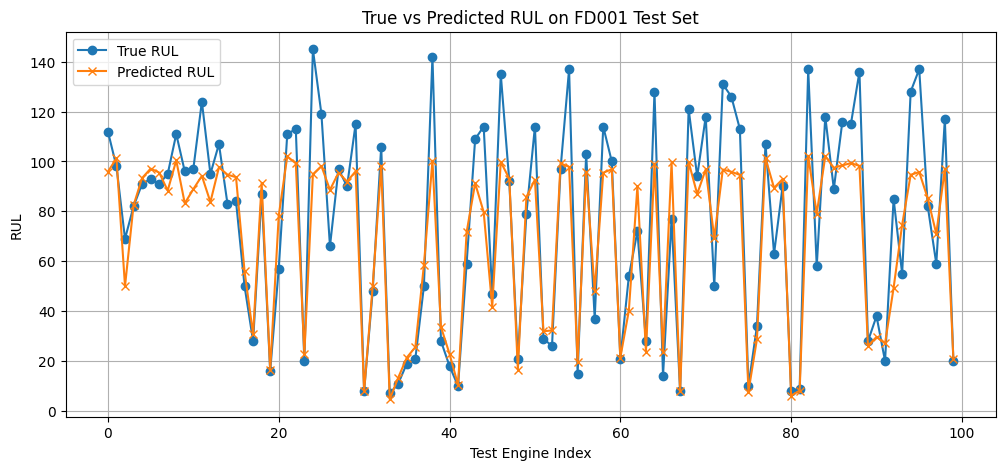

In [67]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True RUL", marker="o")
plt.plot(y_pred, label="Predicted RUL", marker="x")
plt.xlabel("Test Engine Index")
plt.ylabel("RUL")
plt.title("True vs Predicted RUL on FD001 Test Set")
plt.legend()
plt.grid(True)
plt.show()

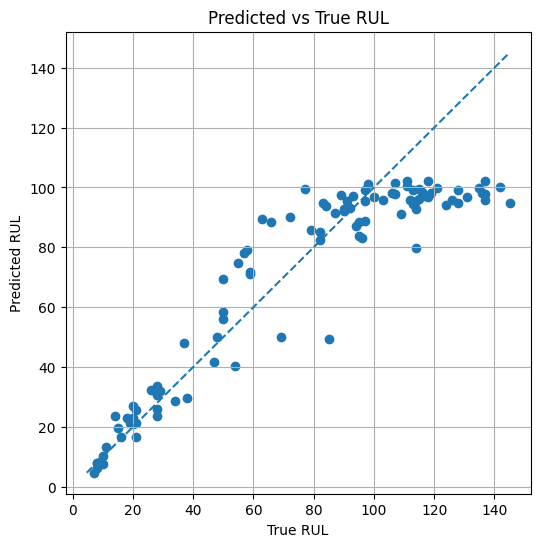

In [68]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred)

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL")
plt.grid(True)
plt.show()

In [69]:
results_df = pd.DataFrame({
    "engine_id": np.arange(1, len(y_true) + 1),
    "true_rul": y_true,
    "predicted_rul": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true)
})

results_df.sort_values("abs_error", ascending=False).head(10)
results_path = RESULTS_DIR / f"{EXPERIMENT_NAME}_predictions.csv"
results_df.to_csv(results_path, index=False)

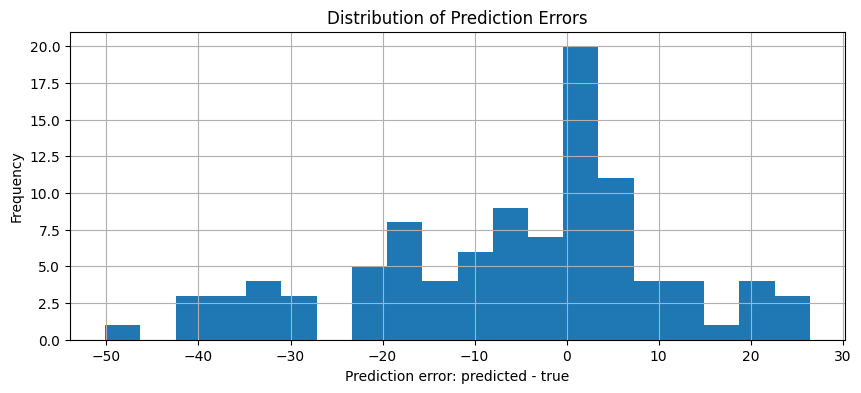

In [70]:
plt.figure(figsize=(10, 4))
plt.hist(results_df["error"], bins=20)
plt.xlabel("Prediction error: predicted - true")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
plt.show()

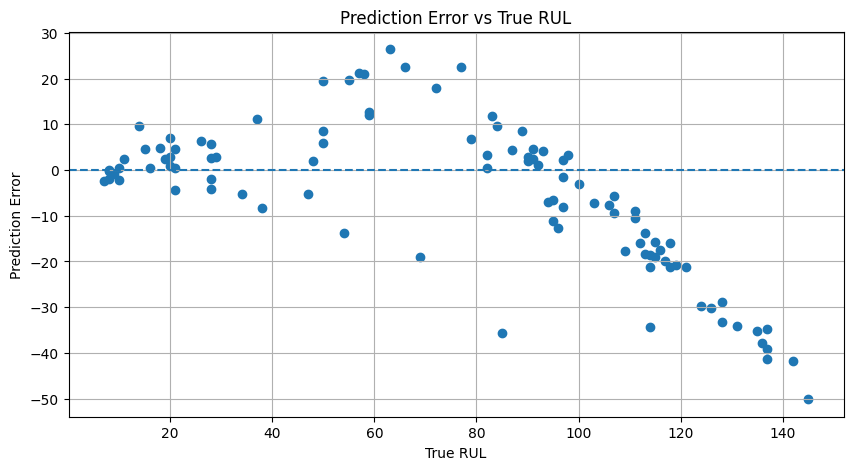

In [71]:
plt.figure(figsize=(10, 5))
plt.scatter(results_df["true_rul"], results_df["error"])
plt.axhline(0, linestyle="--")
plt.xlabel("True RUL")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs True RUL")
plt.grid(True)
plt.show()

In [72]:
def nasa_score(y_true, y_pred):
    errors = y_pred - y_true
    score = 0

    for e in errors:
        if e < 0:
            score += np.exp(-e / 13) - 1
        else:
            score += np.exp(e / 10) - 1

    return score

In [73]:
score = nasa_score(y_true, y_pred)
print("NASA score:", score)

NASA score: 388.3707


In [74]:
summary_path = RESULTS_DIR / "experiment_metrics_summary.csv"

new_row = pd.DataFrame([{
    "experiment": EXPERIMENT_NAME,
    "sequence_length": X_train.shape[1],
    "rul_cap": 100,
    "features": X_train.shape[2],
    "rmse": rmse,
    "mae": mae,
    "r2": r2,
    "nasa_score": score
}])

if summary_path.exists():
    old_df = pd.read_csv(summary_path)
    
    
    old_df = old_df[old_df["experiment"] != EXPERIMENT_NAME]
    
    summary_df = pd.concat([old_df, new_row], ignore_index=True)
else:
    summary_df = new_row

summary_df.to_csv(summary_path, index=False)

summary_df

,experiment,sequence_length,rul_cap,features,rmse,mae,r2,nasa_score
0,lstm_2layer_h128_dropout02_seq30_cap125,30,125,15,14.933655,10.971383,0.870856,407.173920
1,lstm_baseline_seq50_cap125,50,125,15,17.980077,12.138040,0.812792,891.001404
2,lstm_baseline_seq20_cap125,20,125,15,17.224204,12.465150,0.828202,732.156494
3,lstm_baseline_seq30_cap125,30,125,15,14.684165,11.080969,0.875135,335.621765
4,lstm_engine_val_seq30_cap125,30,125,15,14.372617,10.460479,0.880378,304.313324
5,gru_engine_val_seq30_cap125,30,125,15,14.328155,10.473871,0.881117,325.169952
6,lstm_engine_val_seq30_cap125_asym_loss,30,125,15,15.758800,11.247834,0.856191,322.454010
7,lstm_engine_val_seq30_cap150_asym_loss,30,150,15,15.075860,10.877586,0.868385,409.623322
8,lstm_engine_val_seq30_cap150,30,150,15,17.366084,12.630200,0.825360,1178.916504
9,lstm_baseline_seq30_cap150,30,150,15,16.559425,12.318459,0.841207,796.785706
